# Reads Overall

This notebook is for looking at how many reads are in each spot on a sample and a patient. This also includes looking at the level of CD3E and the motochondrial gene percentage.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import squidpy as sq
import os
import seaborn as sns
import re

In [2]:
# List of sample directories
sample_list = [
    "PT-1A", "PT-1C", "PT-2A", "PT-2B", "PT-2C", "PT-3_PRI2", "PT-3A", "PT-3B", "PT-3C", 
    "PT-4A", "PT-4B", "PT-4C", "PT-4D", "PT-5A", "PT-5B", "PT-5C", "PT-6_PRI2", "PT-6_PRI3",
    "PT-6A", "PT-6B", "PT-6C", "PT-6D", "PT-7A", "PT-7B", "PT-7C", "PT-7D", "PT-8_PRI2", 
    "PT-8A", "PT-8B", "PT-8C", "PT-8D", "PT-9A", "PT-9B", "PT-9C", "PT-9D",
    "PT-10A", "PT-10B", "PT-10C", "PT-10D", "PT-11A", "PT-11B", "PT-11C", "PT-11D",
    "PT-12A", "PT-12B", "PT-12C", "PT-12D", "PT-13_PRI2", "PT-13_PRI3", "PT-13A", "PT-13B", "PT-13C", "PT-13D", "PT-13E"
]

# Sample Source
Primary_list = ["PT-1A", "PT-2A", "PT-3A", "PT-3_PRI2", "PT-4A", "PT-5A", "PT-6A", "PT-6_PRI2", "PT-6_PRI3", "PT-7A", "PT-8A", "PT-8_PRI2", "PT-9A", "PT-10A", "PT-11A", "PT-12A", "PT-13A", "PT-13_PRI2", "PT-13_PRI3"]
Lung_list = ["PT-2B", "PT-4C", "PT-10C", "PT-11C", "PT-12C", "PT-13C"]
Liver_list = ["PT-3B", "PT-4B", "PT-5B", "PT-5C", "PT-6B", "PT-7B", "PT-7C", "PT-8B", "PT-8C", "PT-9B", "PT-9C", "PT-10B", "PT-11B", "PT-12B", "PT-13B"]
Peritoneal_list = ["PT-1C", "PT-2C", "PT-3C", "PT-4D", "PT-6C", "PT-6D", "PT-7D", "PT-8D", "PT-9D", "PT-10D", "PT-11D", "PT-12D", "PT-13D", "PT-13E"]


### Loop through all the samples and output corresponding heatmap for read counts

What interesting we found is that the dots with high reads also has a high MetScore. Later, we will take a look at the correlation between the two once we have an optimized MetScore heatmap when we find out the tumor purity of each dot.

In [3]:
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=SyntaxWarning)
warnings.filterwarnings("ignore", category=UserWarning, message="Variable names are not unique")

# setting output directory
output_dir = "/group/jshandl-g00/Spatial-MetScore/Spatial-MetScore/figures/reads_sample"
os.makedirs(output_dir, exist_ok=True)

# List of all spots data
all_spots_data = []

# starting processing all samples
for sample in sample_list:
    sample_upper = sample.upper()
    
    # color matching
    if sample_upper in Primary_list:
        color_hist = "#1f77b4"
        label_group = "Primary"
    elif sample_upper in Lung_list:
        color_hist = "#2ca02c"
        label_group = "Lung"
    elif sample_upper in Liver_list:
        color_hist = "#ff7f0e"
        label_group = "Liver"
    elif sample_upper in Peritoneal_list:
        color_hist = "#d62728"
        label_group = "Peritoneal"
    else:
        color_hist = "#7f7f7f"  
        label_group = "Unknown"
        
    print(f"Processing {sample} ({label_group})...")
    
    sample_dir = f"/group/jshandl-g00/Spatial-MetScore/Spatial-MetScore/data/raw/Samples/{sample}"
    if not os.path.exists(sample_dir):
        print(f"Warning: {sample_dir} not found. Skipping this sample.")
        continue
        
  
    adata = sq.read.visium(path=sample_dir)
    adata.var_names_make_unique()
    sc.pp.calculate_qc_metrics(adata, inplace=True)
    
    # collect data
    sample_df = pd.DataFrame({
        'Reads': adata.obs['total_counts'],
        'Sample': sample  
    })
    all_spots_data.append(sample_df)
    
    median_val = adata.obs['total_counts'].median()
    
    fig, axes = plt.subplots(1, 4, figsize=(24, 5))
    
    # histogram
    sns.histplot(adata.obs['total_counts'], color=color_hist, ax=axes[0], kde=False)
    axes[0].axvline(median_val, color='red', linestyle='--', linewidth=2, label=f'Median: {median_val:.1f}')
    axes[0].set_title(f"Reads Hist - {sample} ({label_group})")
    axes[0].legend()
    
    # H&E
    sq.pl.spatial_scatter(
        adata, 
        img_res_key="hires", 
        img_alpha=1.0,  
        ax=axes[1], 
        title="H&E Original"
    )
    axes[1].set_xlabel('')
    axes[1].set_ylabel('')
    
    # reads
    sq.pl.spatial_scatter(
        adata, 
        color="total_counts", 
        img_res_key="hires",
        cmap="magma_r",  
        img_alpha=0.1,  
        ax=axes[2], 
        title="Raw Total Counts"
    )
    
    # Log1p reads
    adata_log = adata.copy()
    adata_log.obs['log_total_counts'] = np.log1p(adata_log.obs['total_counts'])
    sq.pl.spatial_scatter(
        adata_log, 
        color="log_total_counts", 
        img_res_key="hires",
        cmap="magma_r",  
        img_alpha=0.1, 
        ax=axes[3], 
        title="Log1p Total Counts"
    )
    
    plt.tight_layout()
    save_path = f"{output_dir}/{sample}_combined_report.png"
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.close(fig)

print("All samples processed successfully with updated Squidpy API!")

Processing PT-1A (Primary)...
Processing PT-1C (Peritoneal)...
Processing PT-2A (Primary)...
Processing PT-2B (Lung)...
Processing PT-2C (Peritoneal)...
Processing PT-3_PRI2 (Primary)...
Processing PT-3A (Primary)...
Processing PT-3B (Liver)...
Processing PT-3C (Peritoneal)...
Processing PT-4A (Primary)...
Processing PT-4B (Liver)...
Processing PT-4C (Lung)...
Processing PT-4D (Peritoneal)...
Processing PT-5A (Primary)...
Processing PT-5B (Liver)...
Processing PT-5C (Liver)...
Processing PT-6_PRI2 (Primary)...
Processing PT-6_PRI3 (Primary)...
Processing PT-6A (Primary)...
Processing PT-6B (Liver)...
Processing PT-6C (Peritoneal)...
Processing PT-6D (Peritoneal)...
Processing PT-7A (Primary)...
Processing PT-7B (Liver)...
Processing PT-7C (Liver)...
Processing PT-7D (Peritoneal)...
Processing PT-8_PRI2 (Primary)...
Processing PT-8A (Primary)...
Processing PT-8B (Liver)...
Processing PT-8C (Liver)...
Processing PT-8D (Peritoneal)...
Processing PT-9A (Primary)...
Processing PT-9B (Liver)

### All Patients' Reads Count Histogram

Total spot number: 139685


,Reads,Sample
0,5049.0,PT-1A
1,911.0,PT-1A
2,14305.0,PT-1A
3,8308.0,PT-1A
4,5213.0,PT-1A


Plot saved successfully to: /group/jshandl-g00/Spatial-MetScore/Spatial-MetScore/figures/reads_sample/all_samples_combined_reads_distribution.png


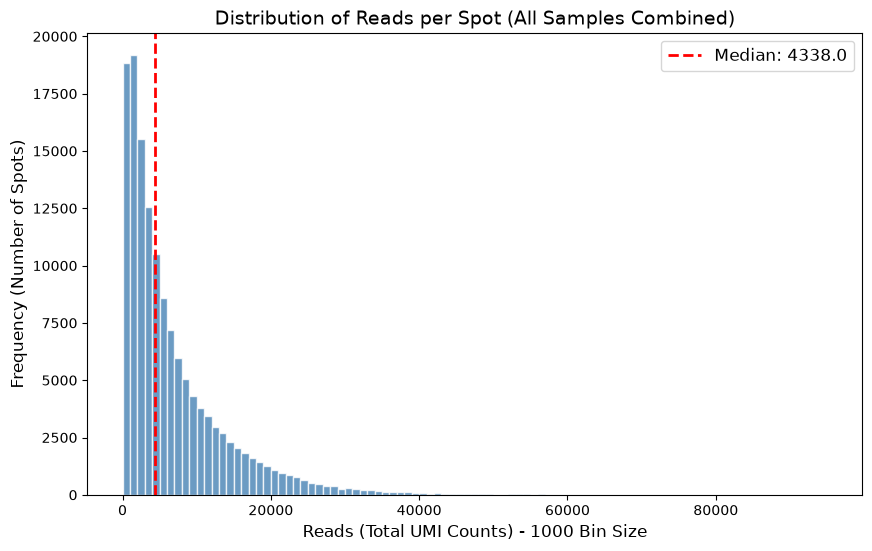

In [4]:
df_all = pd.concat(all_spots_data, ignore_index=True)
print(f"Total spot number: {len(df_all)}")
display(df_all.head()) 


plt.figure(figsize=(10, 6))

max_reads_all = int(df_all['Reads'].max())
bins = range(0, max_reads_all + 1000, 1000)


plt.hist(df_all['Reads'], bins=bins, color='steelblue', edgecolor='white', alpha=0.8)


median_reads = df_all['Reads'].median()
plt.axvline(median_reads, color='red', linestyle='--', linewidth=2, label=f'Median: {median_reads:.1f}')


plt.title('Distribution of Reads per Spot (All Samples Combined)', fontsize=14)
plt.xlabel('Reads (Total UMI Counts) - 1000 Bin Size', fontsize=12)
plt.ylabel('Frequency (Number of Spots)', fontsize=12)


plt.legend(fontsize=12)


output_dir = "/group/jshandl-g00/Spatial-MetScore/Spatial-MetScore/figures/reads_sample"
os.makedirs(output_dir, exist_ok=True)

save_path = f"{output_dir}/all_samples_combined_reads_distribution.png"
plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"Plot saved successfully to: {save_path}")


plt.show()

### Small-Multiple of read counts for patients and samples

Drawing the histogram for reads per patient...


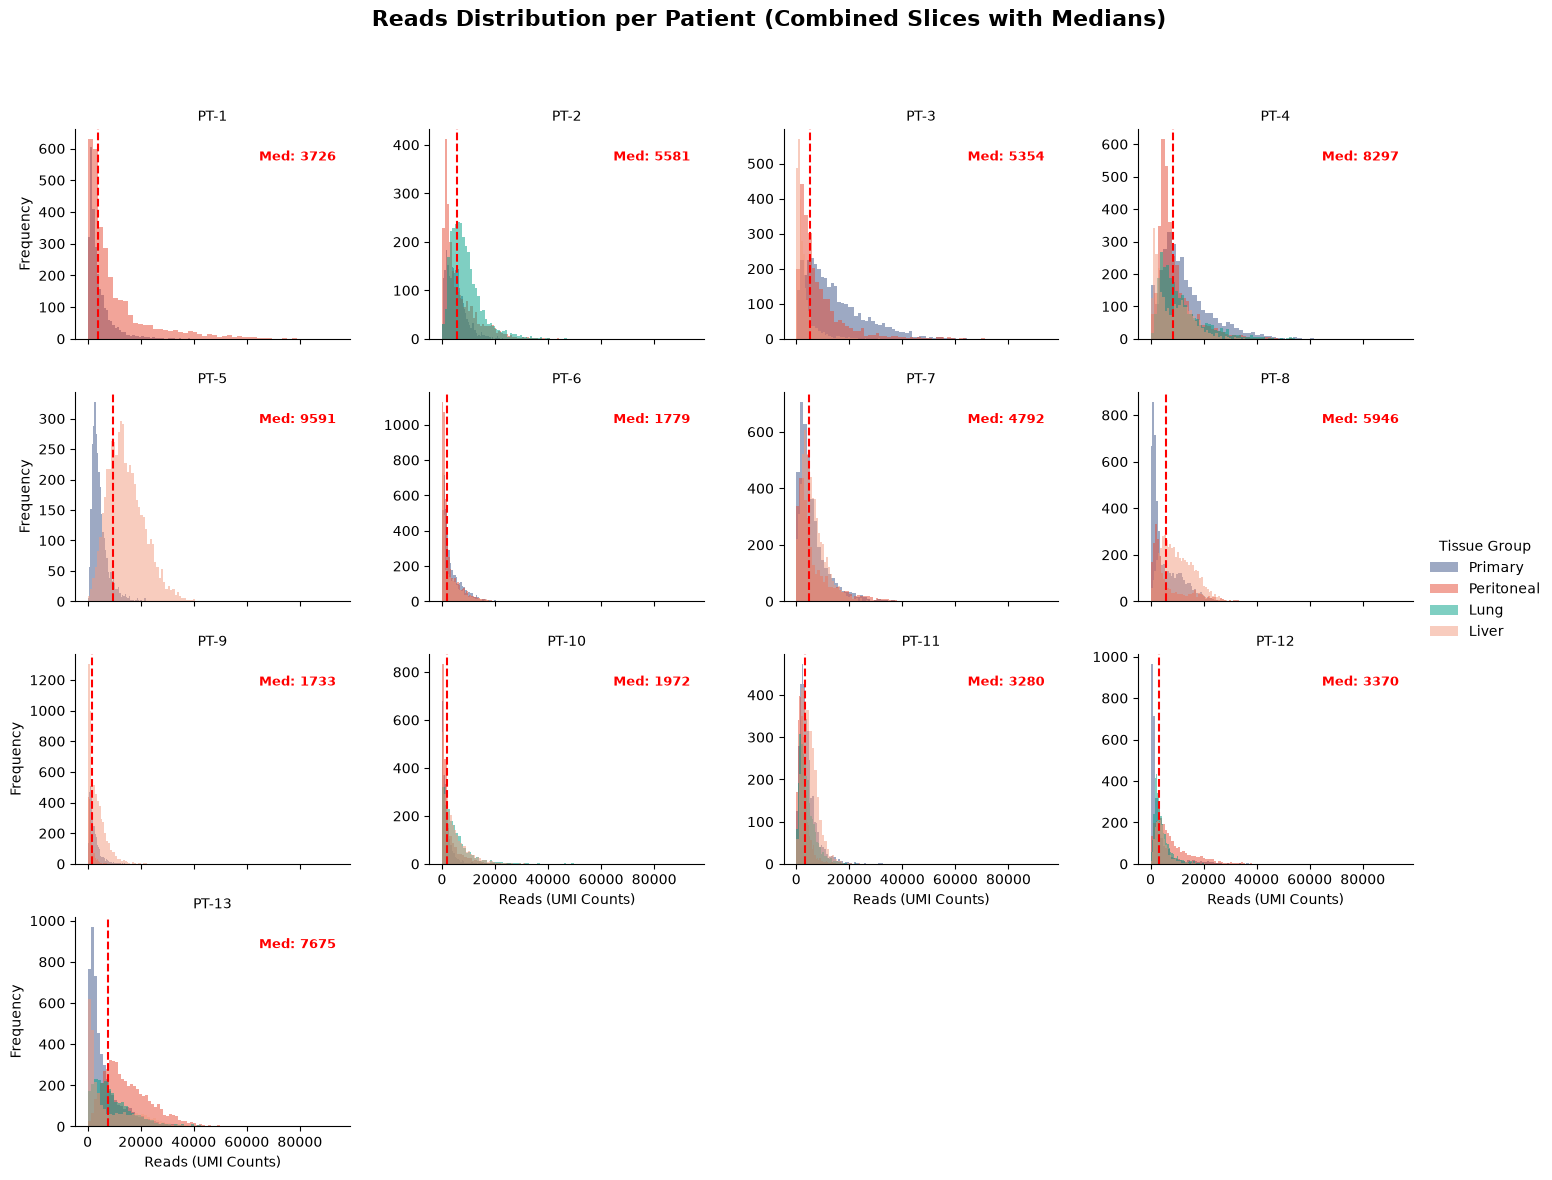

Drawing the histogram for reads per sample...


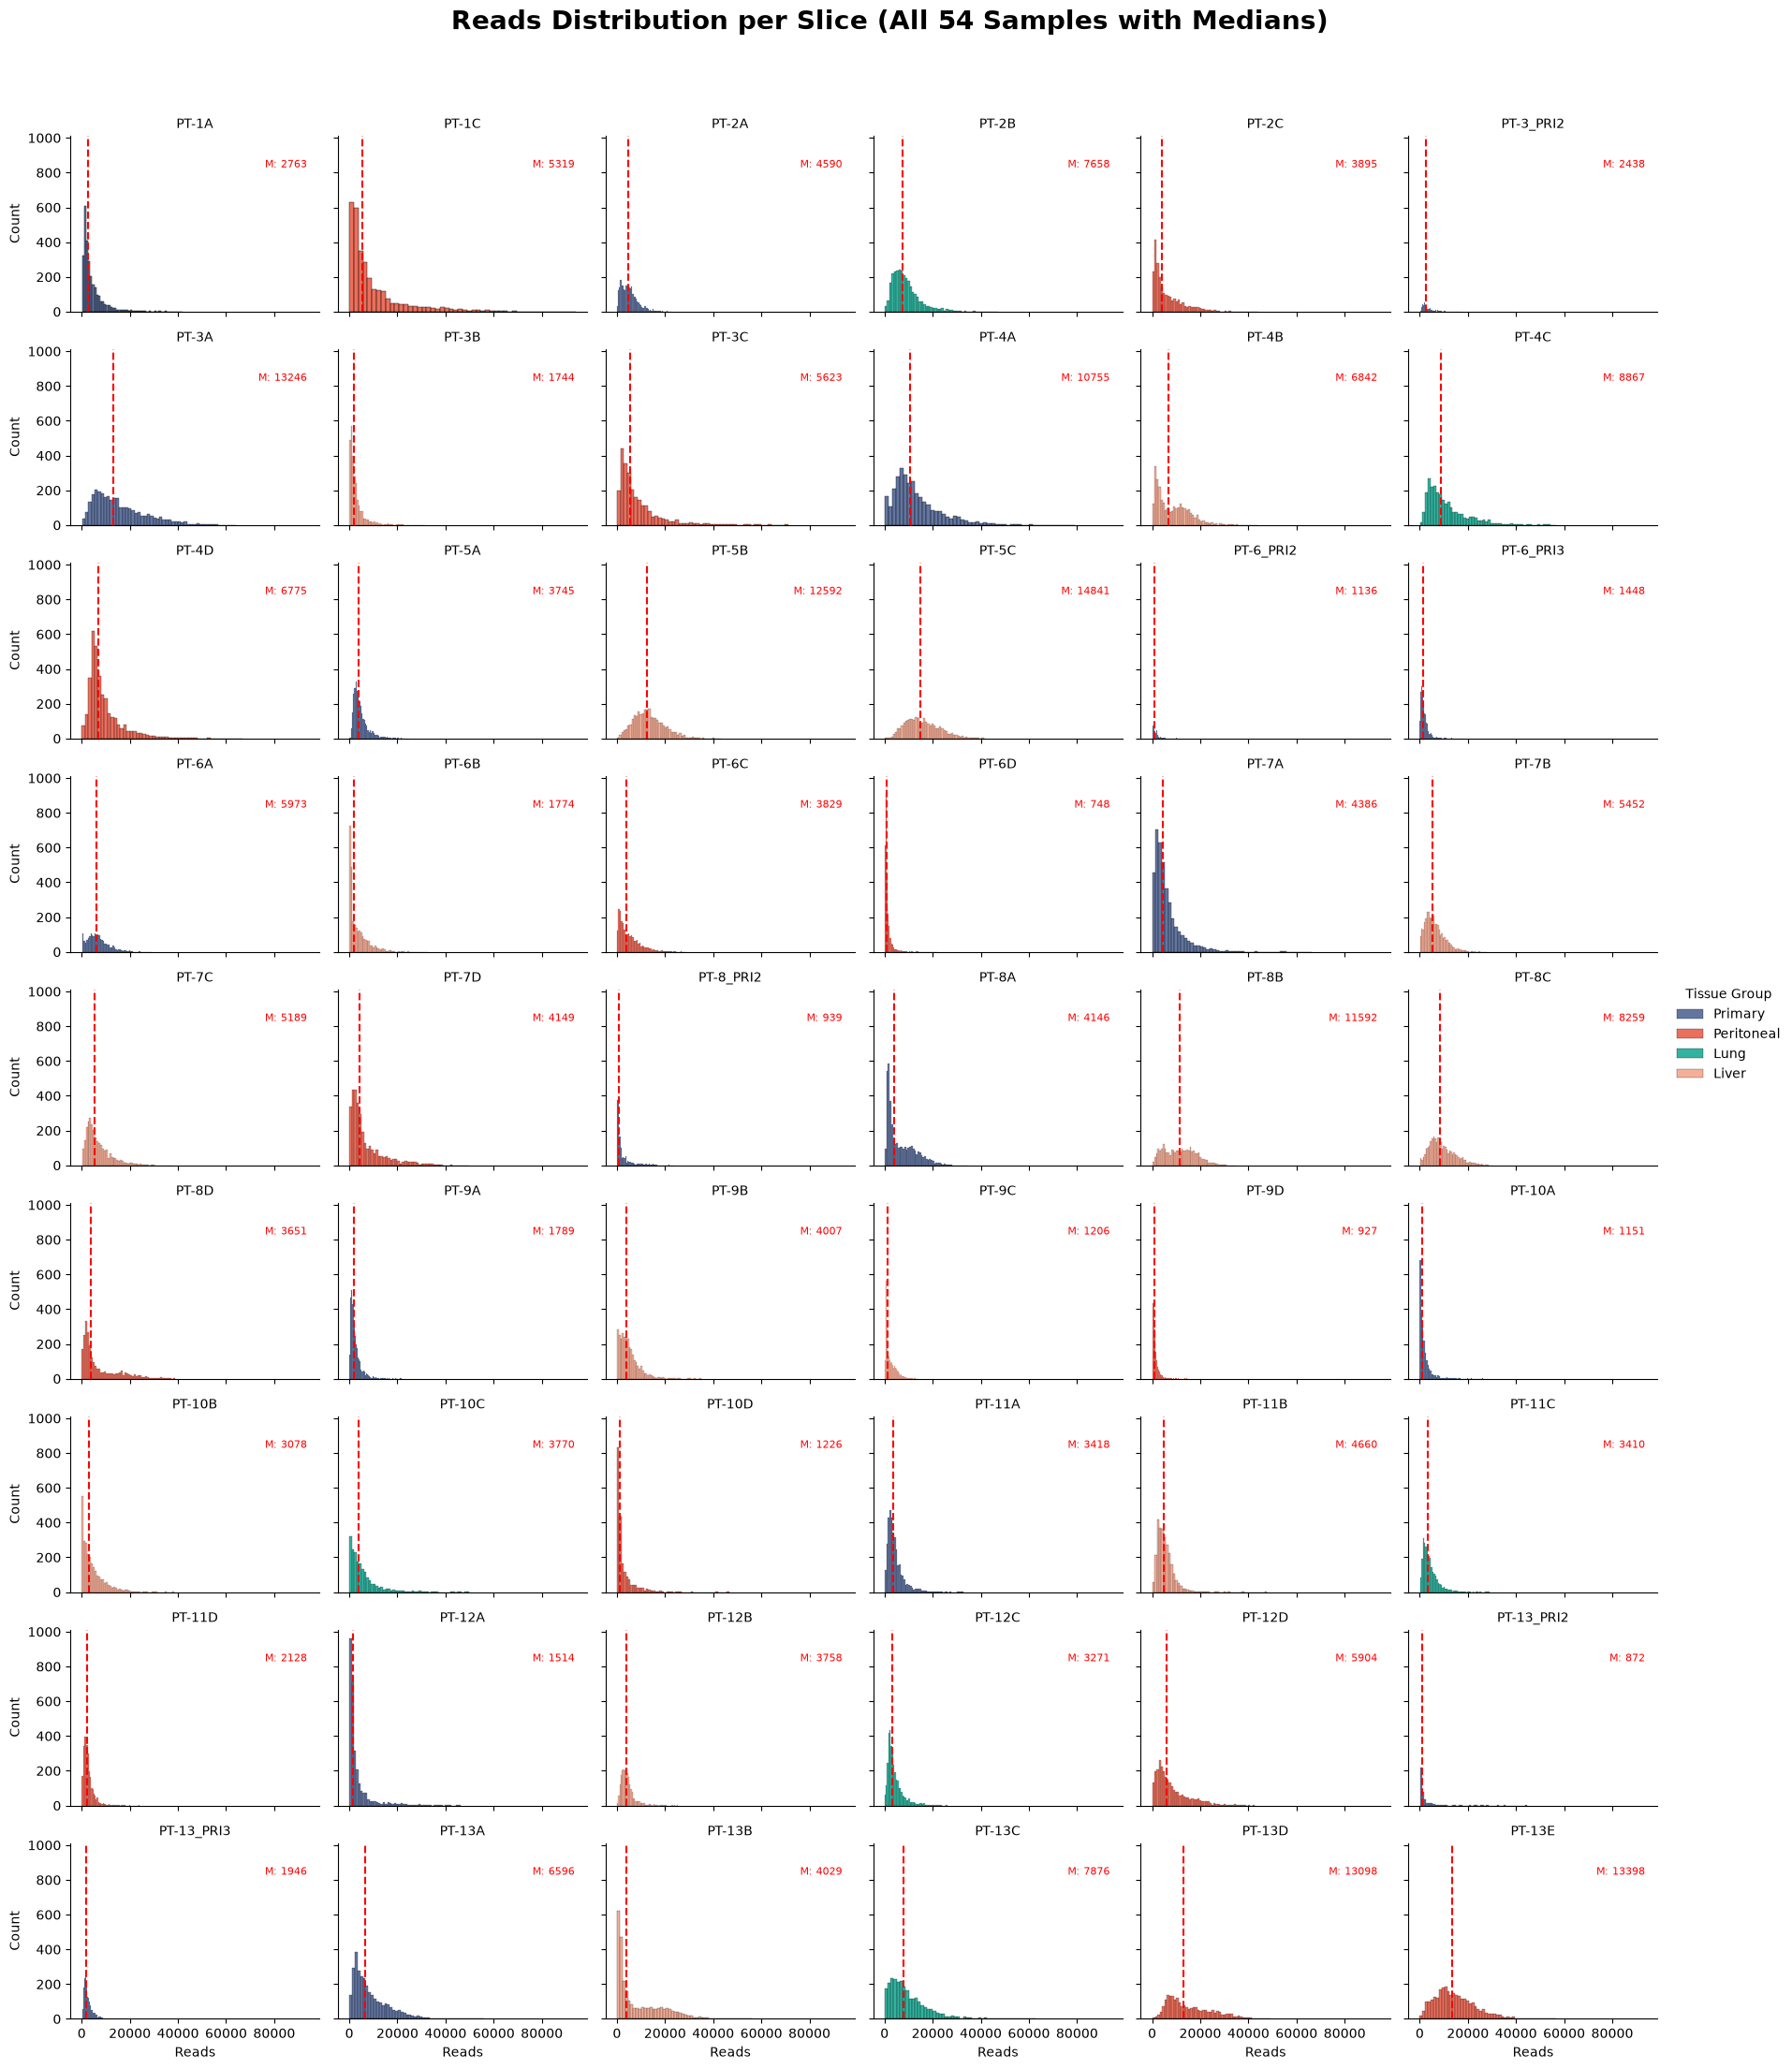

In [7]:
output_dir = "/group/jshandl-g00/Spatial-MetScore/Spatial-MetScore/figures/reads_sample"
os.makedirs(output_dir, exist_ok=True)


def assign_group(sample_name):
    name_upper = sample_name.upper()
    if name_upper in Primary_list: return "Primary"
    if name_upper in Lung_list: return "Lung"
    if name_upper in Liver_list: return "Liver"
    if name_upper in Peritoneal_list: return "Peritoneal"
    return "Unknown"

df_all['Group'] = df_all['Sample'].apply(assign_group)
df_all['Patient'] = df_all['Sample'].apply(lambda x: re.match(r'PT-\d+', x).group())

palette_dict = {
    "Primary": "#3C5488",    # 莫兰迪深蓝 / 灰蓝
    "Lung": "#00A087",       # 翡翠绿 / 青绿
    "Liver": "#F39B7F",      # 柔和桃橘色
    "Peritoneal": "#E64B35", # 砖红色 / 铁锈红
    "Unknown": "#B0B0B0"     # 高级灰
}

# =================================================================
# Reads per Patient 
# =================================================================
print("Drawing the histogram for reads per patient...")

#g_patient = sns.FacetGrid(df_all, col="Patient", col_wrap=4, sharex=True, sharey=True, height=3, aspect=1.2, hue="Group", palette=palette_dict)
g_patient = sns.FacetGrid(df_all, col="Patient", col_wrap=4, sharex=True, sharey=False, height=3, aspect=1.2, hue="Group", palette=palette_dict)
#g_patient.map_dataframe(sns.histplot, x="Reads", bins=50, alpha=0.8, multiple="stack")
g_patient.map_dataframe(sns.histplot, x="Reads", bins=50, alpha=0.5, multiple="layer", linewidth=0)

g_patient.set_titles(col_template="{col_name}")
g_patient.set_axis_labels("Reads (UMI Counts)", "Frequency")


for ax in g_patient.axes.flat:
    patient_id = ax.get_title()
    if patient_id:
        sub_data = df_all[df_all['Patient'] == patient_id]
        if not sub_data.empty:
            p_median = sub_data['Reads'].median()
            ax.axvline(p_median, color='red', linestyle='--', linewidth=1.5)
            ax.text(0.95, 0.85, f'Med: {p_median:.0f}', transform=ax.transAxes, color='red', fontsize=9, ha='right', fontweight='bold')

g_patient.add_legend(title="Tissue Group")
plt.subplots_adjust(top=0.88) 
g_patient.fig.suptitle('Reads Distribution per Patient (Combined Slices with Medians)', fontsize=16, fontweight='bold')

patient_save_path = f"{output_dir}/Hist_SmallMultiples_by_Patienty.png"
plt.savefig(patient_save_path, dpi=300, bbox_inches='tight')
plt.show()


# =================================================================
# Reads per Sample
# =================================================================
print("Drawing the histogram for reads per sample...")

g_sample = sns.FacetGrid(df_all, col="Sample", col_wrap=6, sharex=True, sharey=True, height=2.5, aspect=1.2, hue="Group", palette=palette_dict)
g_sample.map_dataframe(sns.histplot, x="Reads", bins=50, alpha=0.8)

g_sample.set_titles(col_template="{col_name}")
g_sample.set_axis_labels("Reads", "Count")


for ax in g_sample.axes.flat:
    sample_id = ax.get_title()
    if sample_id:
        sub_data = df_all[df_all['Sample'] == sample_id]
        if not sub_data.empty:
            s_median = sub_data['Reads'].median()
            ax.axvline(s_median, color='red', linestyle='--', linewidth=1.5)
            ax.text(0.95, 0.82, f'M: {s_median:.0f}', transform=ax.transAxes, color='red', fontsize=8, ha='right')

g_sample.add_legend(title="Tissue Group")
plt.subplots_adjust(top=0.92)
g_sample.fig.suptitle('Reads Distribution per Slice (All 54 Samples with Medians)', fontsize=20, fontweight='bold')

slice_save_path = f"{output_dir}/Hist_SmallMultiples_by_Slicey.png"
plt.savefig(slice_save_path, dpi=300, bbox_inches='tight')
plt.show()

### Normalizing Read Counts


| **Low Counts** | **Intermediate Counts** | **High Counts** |
| :--- | :--- | :--- |
| Necrotic core (dead cells) | Tumor Stroma (fibroblasts) | Highly proliferative tumor nests |
| Empty glass background | Dense fibrosis / collagen | Active cloning |
| Artifacts / PCR duplicates | Immune Infiltrate (T-cells) | Normal adjacent tissue |


### CD3E Spatial Expression
**The CD3 Gene & CD3E**

The CD3 gene encodes the Cluster of Differentiation 3 protein complex found on the surface of all mature T cells.
- CD3 Complex: A multi-protein chain (gamma, delta, epsilon, zeta) that pairs with the T-cell receptor (TCR).
- CD3E: The specific gene that encodes the epsilon ($\epsilon$) chain of this complex.
- Function: It acts as a signaling transmitter. When the TCR detects an antigen, CD3 sends the activation signal inside the T cell.

**Key Representations**
- T-Cell Marker: Used in flow cytometry and histology to uniquely identify and isolate T cells.
- Clinical Target: Targeted by immunotherapies (like BiTEs) to direct T cells to kill cancer cells.
- Immune Health: Mutations in CD3E cause Severe Combined Immunodeficiency (SCID).

Saved!


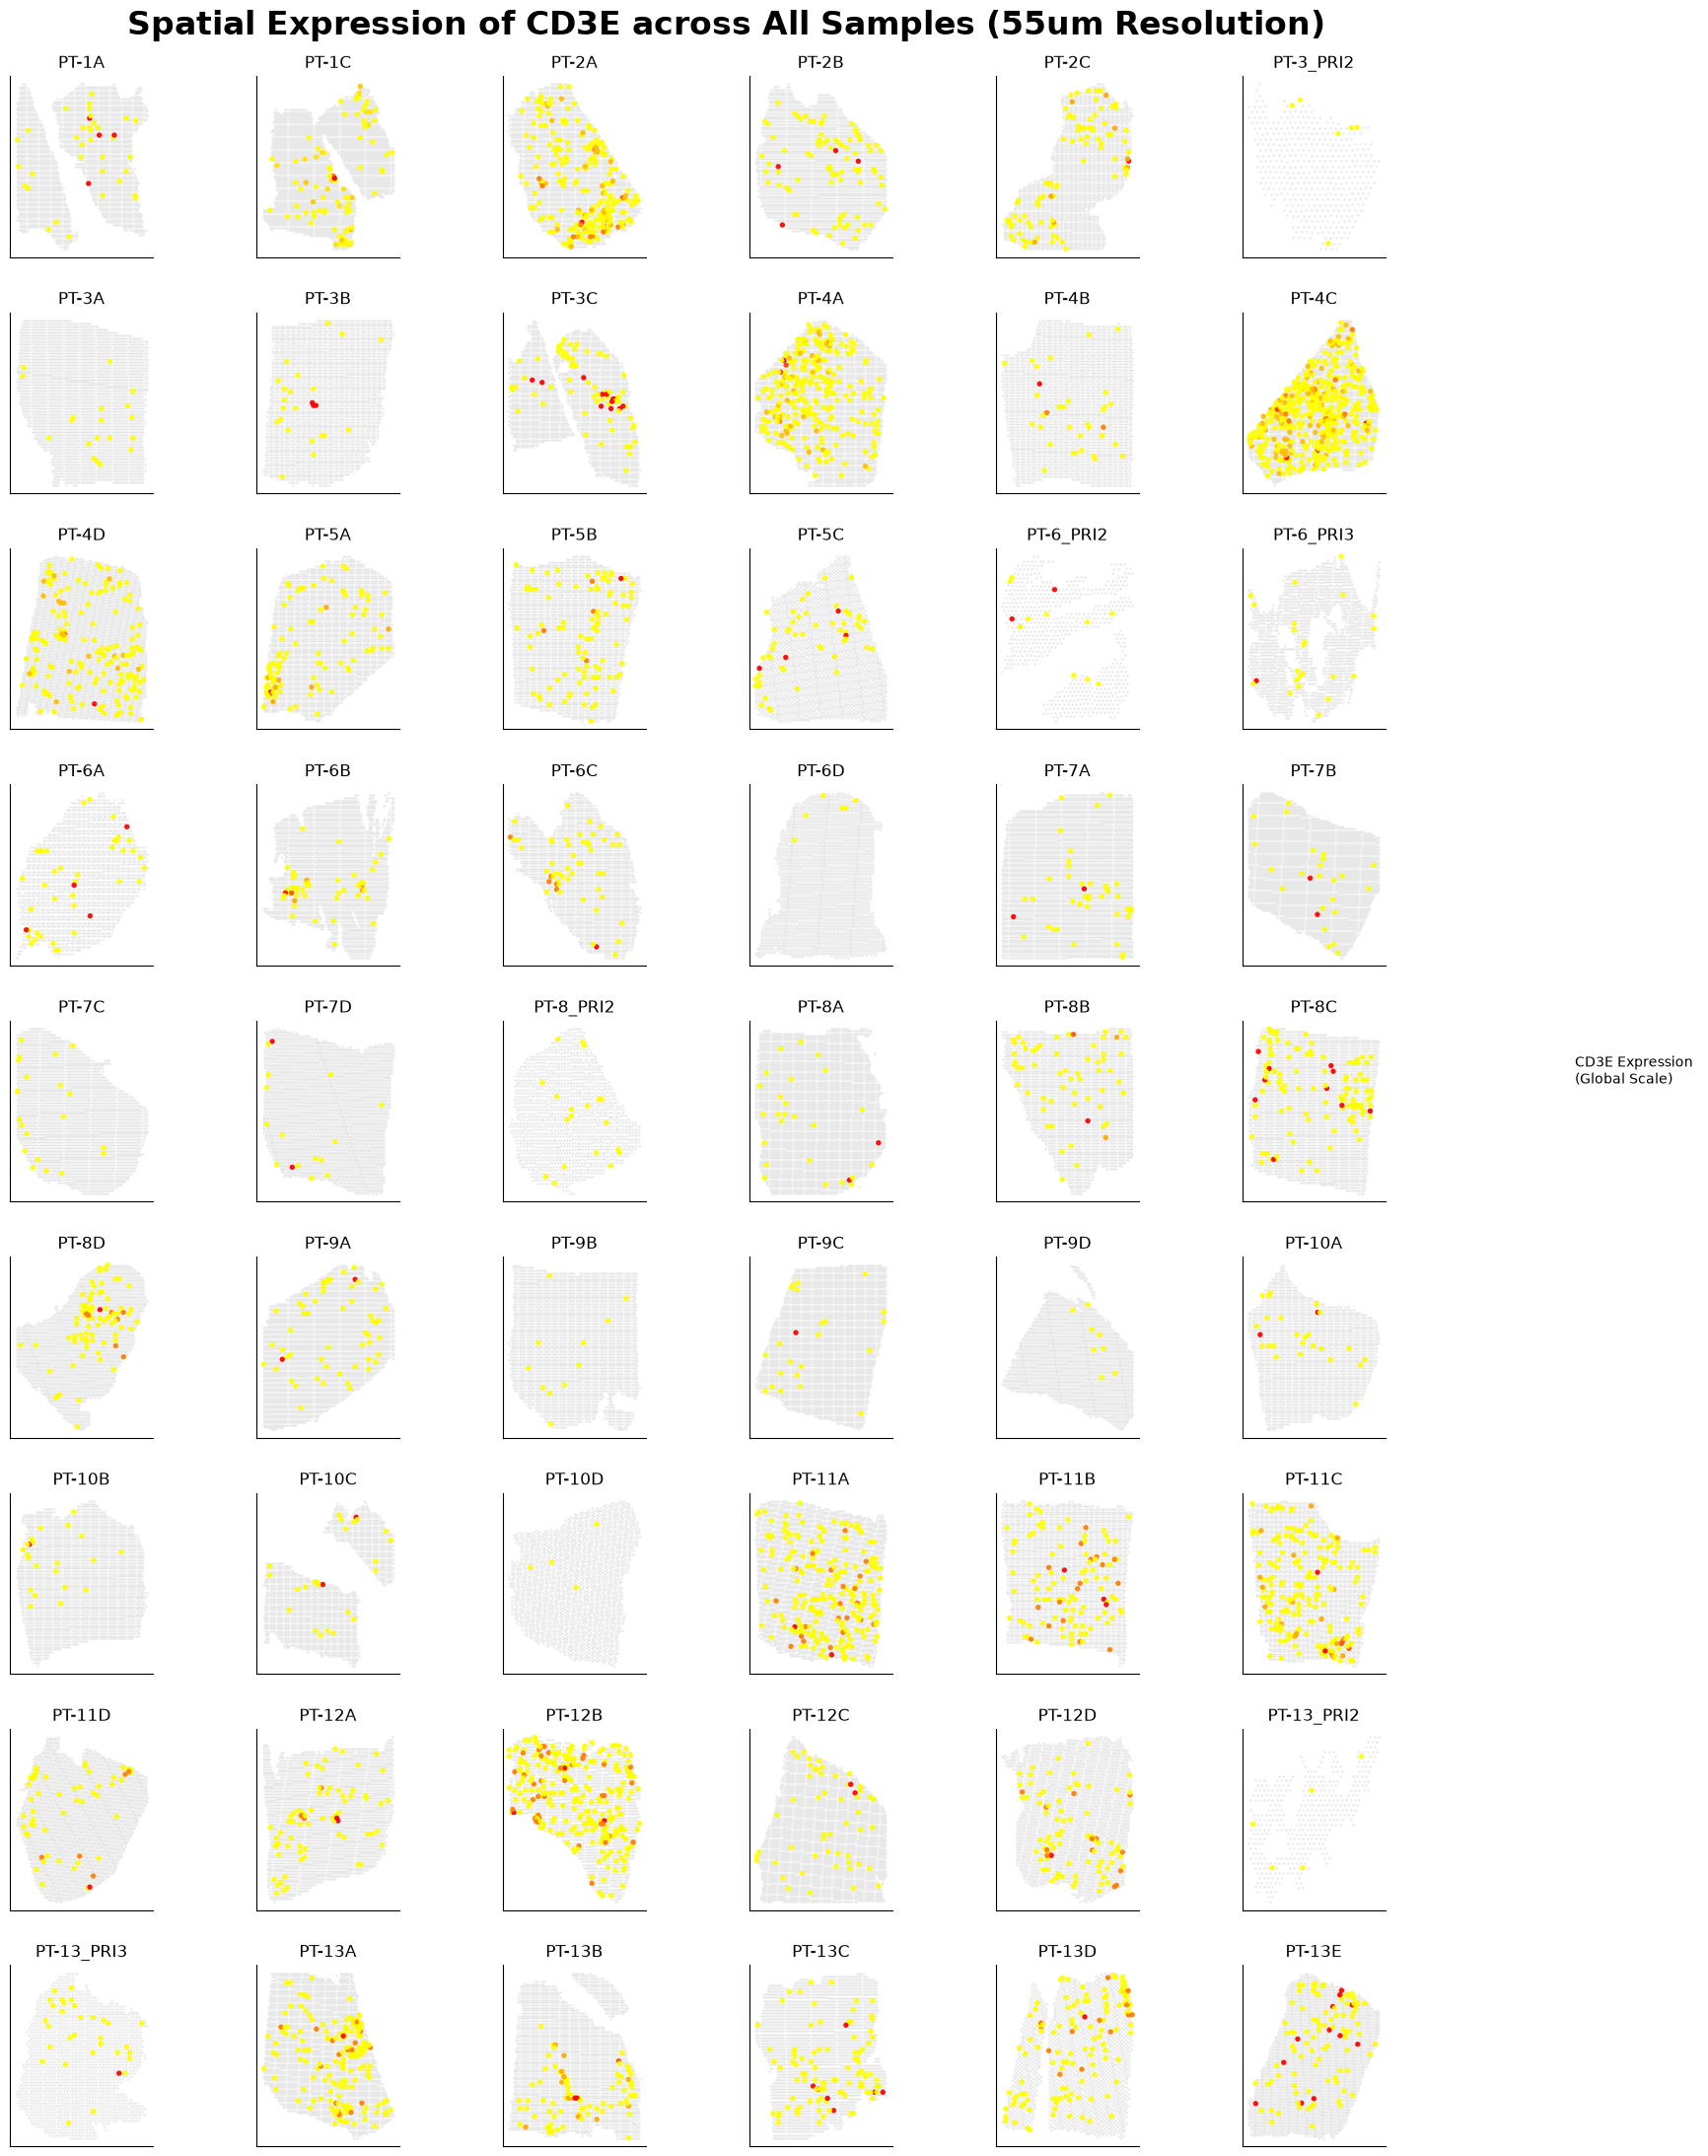

In [9]:
warnings.filterwarnings("ignore")

target_gene = "CD3E" 
all_spots_gene = []



for sample in sample_list:
    sample_dir = f"/group/jshandl-g00/Spatial-MetScore/Spatial-MetScore/data/raw/Samples/{sample}"
    
    try:
       
        adata = sc.read_visium(path=sample_dir)
        adata.var_names_make_unique()
        
        coords = adata.obsm['spatial']
        
        if target_gene in adata.var_names:
            expr = adata[:, target_gene].X.toarray().flatten()
        else:
            expr = [0] * adata.n_obs
            
        df_temp = pd.DataFrame({
            'X': coords[:, 0],
            'Y': -coords[:, 1], 
            'Expression': expr,
            'Sample': sample
        })
        all_spots_gene.append(df_temp)
        
        
    except Exception as e:
        print(f"Failed to read {sample}: {e}")

# combine the data
df_gene = pd.concat(all_spots_gene, ignore_index=True)


# drawing
global_max = df_gene['Expression'].max()
g = sns.FacetGrid(df_gene, col="Sample", col_wrap=6, sharex=False, sharey=False, height=2.5, aspect=1)


def custom_spatial_plot(data, **kwargs):
    # the first layer
    zero_data = data[data['Expression'] == 0]
    plt.scatter(zero_data['X'], zero_data['Y'], c='#E0E0E0', s=1, edgecolor=None, alpha=0.5)
    
    # the second layer
    pos_data = data[data['Expression'] > 0]
    if not pos_data.empty:
        # robust=True
        scatter = plt.scatter(pos_data['X'], pos_data['Y'], c=pos_data['Expression'], 
                              cmap='autumn_r', s=8, edgecolor=None, alpha=0.9)

g.map_dataframe(custom_spatial_plot)
#g.map_dataframe(sns.scatterplot, x="X", y="Y", hue="Expression", palette="magma", s=2, edgecolor=None, hue_norm=(0, global_max))

g.set(xticks=[], yticks=[], xlabel='', ylabel='')
g.set_titles(col_template="{col_name}", size=12)

g.add_legend(title=f"{target_gene} Expression\n(Global Scale)", bbox_to_anchor=(1.02, 0.5), loc='center left')
plt.subplots_adjust(top=0.95)
g.fig.suptitle(f'Spatial Expression of {target_gene} across All Samples (55um Resolution)', fontsize=24, fontweight='bold')

# save
save_dir = "/group/jshandl-g00/Spatial-MetScore/Spatial-MetScore/figures/reads_sample"
os.makedirs(save_dir, exist_ok=True) 

save_path = os.path.join(save_dir, f"{target_gene}_Spatial_SmallMultiples.png")
g.savefig(save_path, dpi=300, bbox_inches='tight')

print("Saved!")
plt.show()

### Check the Mitochondrial gene percentage

Mitochondrial genes always start with the prefix `MT-` (in humans) or `mt-` (in mice). When a cell dies or gets damaged during processing, its normal cytoplasmic RNA leaks out, but the tough mitochondrial membranes trap the mito RNA inside. Therefore, a spot with a very high mito percentage usually represents a dead, dying, or necrotic area of the tumor.

- Normal/Healthy Tumor Threshold: In standard single-cell RNA-seq, anything above 5% to 10% mito is considered dead. However, for Visium tumor slices, it is common to see spots up to 20% or even 30% mito in certain areas.

- High Mito Clusters: If you see specific clusters of spots on your image where the mito percentage spikes drastically (e.g., >30%), overlay that with your H&E image. These almost always align with necrotic cores (dead centers of the tumor) or heavily hypoxic regions.

- Low Mito Clusters: The highly proliferative, active "invasive edge" of the tumor will usually have low mitochondrial percentages but very high overall UMI counts (contributing to your right-skew).

Loading data for PT-1A...
Calculating mitochondrial gene percentage...

=== PT-1A Mitochondrial Gene Percentage (pct_counts_mt) Statistics ===
count    2753.000000
mean        1.268628
std         1.392519
min         0.000000
25%         0.360911
50%         0.919098
75%         1.605137
max        14.647887
Name: pct_counts_mt, dtype: float64
Done! Mitochondrial spatial heatmap saved to: /group/jshandl-g00/Spatial-MetScore/Spatial-MetScore/figures/reads_sample/PT-1A_MT_heatmap.png


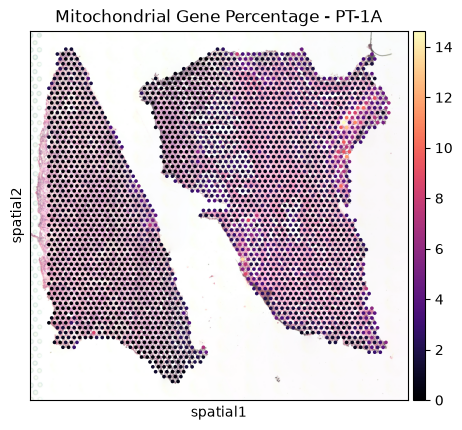

In [10]:
# set the sample
sample = "PT-1A"
sample_dir = f"/group/jshandl-g00/Spatial-MetScore/Spatial-MetScore/data/raw/Samples/{sample}"

print(f"Loading data for {sample}...")
adata = sc.read_visium(path=sample_dir)
adata.var_names_make_unique() 

# Looking for Mitochondrial genes
adata.var['mt'] = adata.var_names.str.startswith('MT-')

# Quality Control Metrics
print("Calculating mitochondrial gene percentage...")
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)

# Print mitochondrial gene percentage statistics
print(f"\n=== {sample} Mitochondrial Gene Percentage (pct_counts_mt) Statistics ===")
print(adata.obs['pct_counts_mt'].describe())

# Violin plot
save_dir = "/group/jshandl-g00/Spatial-MetScore/Spatial-MetScore/figures/reads_sample"
os.makedirs(save_dir, exist_ok=True)

sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], 
             jitter=0.4, multi_panel=True, show=False)
plt.savefig(os.path.join(save_dir, f"{sample}_QC_Violin.png"), bbox_inches='tight', dpi=300)
plt.close()

# Draw the spatial heatmap for mitochondrial gene percentage
ax = sc.pl.spatial(
    adata, 
    color="pct_counts_mt",
    cmap="magma",
    title=f"Mitochondrial Gene Percentage - {sample}",
    #spot_size=1.5,
    alpha_img=0.7, 
    show=False
)

save_path = os.path.join(save_dir, f"{sample}_MT_heatmap.png")
plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"Done! Mitochondrial spatial heatmap saved to: {save_path}")
plt.show() 